# Dedicated Binary XGBoost Golf Detector Model

This notebook trains a binary classifier to detect golf swing videos using:
- **GolfDB (Positives, Class 1):** ~394k frames from 1,399 videos.
- **UCF50 (Negatives, Class 0):** ~304k frames from 1,500 non-golf videos.

It trains on the 98 normalized coordinate and offset features, excluding metadata columns to prevent data leakage.

In [1]:
# Import required libraries
%load_ext autoreload
%autoreload 2

import os
import sys
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, precision_recall_curve, auc, confusion_matrix, roc_curve

# Set project root path relative to this notebook's directory
PROJECT_ROOT = os.path.abspath("../")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.feature_engineer import engineer_sliding_window

## 1. Data Merging and Preprocessing

We load both `master_training_dataset.csv` (GolfDB) and the 1,500 UCF non-golf video CSVs. We keep only features starting with `norm_` and the target label.

We then save the merged dataset to `data/processed/binary_detector_dataset.csv` for easy re-running.

In [2]:
master_dataset_path = os.path.join(PROJECT_ROOT, "data/processed/master_dataset.csv")
print("Loading master dataset...")
df_binary = pd.read_csv(master_dataset_path)
print(f"Loaded master dataset: {df_binary.shape}")
print(df_binary["is_golf"].value_counts())

Loading master dataset...
Loaded master dataset: (721468, 110)
is_golf
1    393899
0    327569
Name: count, dtype: int64


/var/folders/4c/nvx1mdln0kl4lvn21s4q6m340000gn/T/ipykernel_82263/496552042.py:3: DtypeWarning: Columns (0: video_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_binary = pd.read_csv(master_dataset_path)


## 2. Reload Merged Dataset (Fast Entrypoint)

If you have already run the cell above once, you can start directly here. This loads the saved, memory-optimized combined dataset from disk.

## 3. Perform Group Train/Val/Test Split on Video ID (80/10/10)

To prevent data leakage, we perform a group split on unique `video_id`s, ensuring that frames from the same video are kept entirely in either the train, validation, or test sets. Shuffling is done using a fixed random seed (`42`) for reproducibility.

In [3]:
unique_video_ids = df_binary["video_id"].unique()
print(f"Total unique videos: {len(unique_video_ids)}")

np.random.seed(42)
np.random.shuffle(unique_video_ids)

num_videos = len(unique_video_ids)
split_train = int(num_videos * 0.8)
split_val = int(num_videos * 0.9)

train_vids = unique_video_ids[:split_train]
val_vids = unique_video_ids[split_train:split_val]
test_vids = unique_video_ids[split_val:]

print(f"Train videos: {len(train_vids)} ({len(train_vids)/num_videos:.1%})")
print(f"Val videos: {len(val_vids)} ({len(val_vids)/num_videos:.1%})")
print(f"Test videos: {len(test_vids)} ({len(test_vids)/num_videos:.1%})")

# Filter dataframes based on split video IDs
df_train = df_binary[df_binary["video_id"].isin(train_vids)].copy()
df_val = df_binary[df_binary["video_id"].isin(val_vids)].copy()
df_test = df_binary[df_binary["video_id"].isin(test_vids)].copy()

print(f"\nTrain frames: {len(df_train)}")
print(f"Val frames: {len(df_val)}")
print(f"Test frames: {len(df_test)}")

Total unique videos: 3042
Train videos: 2433 (80.0%)
Val videos: 304 (10.0%)
Test videos: 305 (10.0%)

Train frames: 579203
Val frames: 72753
Test frames: 69512


## 4. Feature Selection

We select the 98 normalized coordinates and offsets as our training features. We exclude metadata columns (`view`, `sex`, `club`) to prevent data leakage.

In [4]:
feature_cols = sorted([c for c in df_binary.columns if c.startswith("norm_")])
print(f"Pose features (norm_): {len(feature_cols)}")

X_train = df_train[feature_cols]
y_train = df_train["is_golf"]

X_val = df_val[feature_cols]
y_val = df_val["is_golf"]

X_test = df_test[feature_cols]
y_test = df_test["is_golf"]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Pose features (norm_): 98
X_train shape: (579203, 98), y_train shape: (579203,)


## 5. Train XGBoost Binary Classifier

We train an `XGBClassifier` with the `binary:logistic` objective, enabling early stopping based on validation loss.

In [5]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="binary:logistic",
    tree_method="hist",
    random_state=42
)

print("Training XGBClassifier with early stopping...")
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=10
)
print("Training completed!")

Training XGBClassifier with early stopping...
[0]	validation_0-logloss:0.61041
[10]	validation_0-logloss:0.29478
[20]	validation_0-logloss:0.20951
[30]	validation_0-logloss:0.17932
[40]	validation_0-logloss:0.16826
[50]	validation_0-logloss:0.16303
[60]	validation_0-logloss:0.15828
[70]	validation_0-logloss:0.15388
[80]	validation_0-logloss:0.15045
[90]	validation_0-logloss:0.14595
[100]	validation_0-logloss:0.14245
[110]	validation_0-logloss:0.14009
[120]	validation_0-logloss:0.13725
[130]	validation_0-logloss:0.13602
[140]	validation_0-logloss:0.13365
[150]	validation_0-logloss:0.13185
[160]	validation_0-logloss:0.13082
[170]	validation_0-logloss:0.12813
[180]	validation_0-logloss:0.12651
[190]	validation_0-logloss:0.12661
[200]	validation_0-logloss:0.12655
[210]	validation_0-logloss:0.12583
[220]	validation_0-logloss:0.12543
[230]	validation_0-logloss:0.12376
[240]	validation_0-logloss:0.12216
[250]	validation_0-logloss:0.12103
[260]	validation_0-logloss:0.12151
[270]	validation_0-l

## 6. Save the Binary Model

We serialize the trained booster to JSON format.

In [6]:
models_dir = os.path.join(PROJECT_ROOT, "models")
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, "golf_binary_detector.json")

model.save_model(model_path)
print(f"Saved serialized model to: {model_path}")

Saved serialized model to: /Users/sagar/Documents/ML/golf-analysis/models/golf_binary_detector.json


## 7. Frame-Level Performance Evaluation

We compute precision, recall, confusion matrix, and precision-recall curve on the holdout test set at the individual frame level.

In [7]:
# Get predicted probabilities
y_prob = model.predict_proba(X_test)[:, 1]
# Standard threshold of 0.5
y_pred = (y_prob >= 0.5).astype(int)

print(f"Frame-Level Test Set Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Frame-Level Classification Report (Threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=["Non-Golf", "Golf"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Frame-Level Test Set Accuracy: 0.9643

Frame-Level Classification Report (Threshold = 0.5):
              precision    recall  f1-score   support

    Non-Golf       0.97      0.96      0.96     35001
        Golf       0.96      0.97      0.96     34511

    accuracy                           0.96     69512
   macro avg       0.96      0.96      0.96     69512
weighted avg       0.96      0.96      0.96     69512

Confusion Matrix:
[[33525  1476]
 [ 1003 33508]]


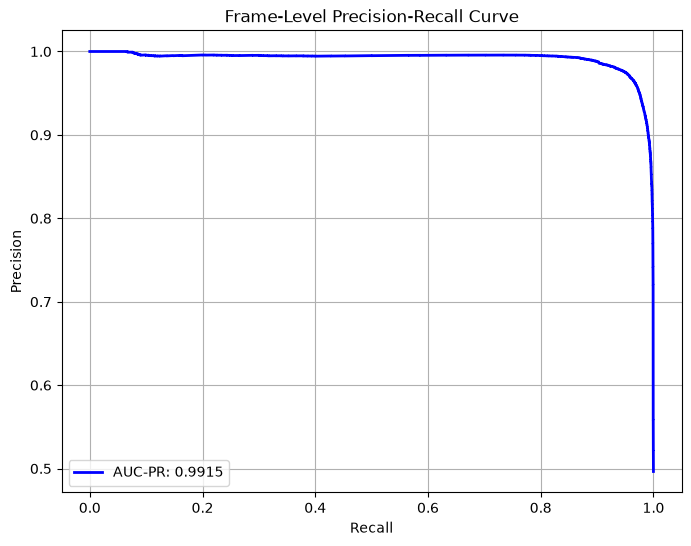

Optimal Threshold (maximizing F1): 0.6033
Max F1-Score: 0.9650 (Precision: 0.9656, Recall: 0.9645)


In [8]:
# Plot Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
auc_pr = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"AUC-PR: {auc_pr:.4f}", color="blue", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Frame-Level Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Find optimal threshold maximizing F1 score
f1_scores = 2 * recall * precision / (recall + precision + 1e-10)
opt_idx = np.argmax(f1_scores)
opt_threshold = thresholds[min(opt_idx, len(thresholds)-1)]
print(f"Optimal Threshold (maximizing F1): {opt_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[opt_idx]:.4f} (Precision: {precision[opt_idx]:.4f}, Recall: {recall[opt_idx]:.4f})")

## 8. Video-Level Performance Evaluation

Since golf classification is typically done per-video, we can aggregate frame-level predictions to classify entire videos. A simple aggregation strategy is to take the average (or maximum) probability of the frames in each video.

In [9]:
# Group the test predictions by video_id
df_test_eval = df_test.copy()
df_test_eval["pred_prob"] = y_prob

# Compute video-level ground truth and average probability
video_eval = df_test_eval.groupby("video_id").agg({
    "is_golf": "first",
    "pred_prob": "mean"
}).reset_index()

y_video_true = video_eval["is_golf"]
y_video_prob = video_eval["pred_prob"]

# Optimize threshold at video level
v_precision, v_recall, v_thresholds = precision_recall_curve(y_video_true, y_video_prob)
v_f1_scores = 2 * v_recall * v_precision / (v_recall + v_precision + 1e-10)
v_opt_idx = np.argmax(v_f1_scores)
v_opt_threshold = v_thresholds[min(v_opt_idx, len(v_thresholds)-1)]

y_video_pred = (y_video_prob >= v_opt_threshold).astype(int)

print("Video-Level Performance:")
print(f"Optimal Video-Level Threshold: {v_opt_threshold:.4f}")
print(f"Video-Level Classification Report (Threshold = {v_opt_threshold:.4f}):")
print(classification_report(y_video_true, y_video_pred, target_names=["Non-Golf", "Golf"]))

v_cm = confusion_matrix(y_video_true, y_video_pred)
print("Video-Level Confusion Matrix:")
print(v_cm)

Video-Level Performance:
Optimal Video-Level Threshold: 0.7346
Video-Level Classification Report (Threshold = 0.7346):
              precision    recall  f1-score   support

    Non-Golf       0.98      1.00      0.99       181
        Golf       1.00      0.97      0.98       124

    accuracy                           0.99       305
   macro avg       0.99      0.98      0.99       305
weighted avg       0.99      0.99      0.99       305

Video-Level Confusion Matrix:
[[181   0]
 [  4 120]]
